In [2]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

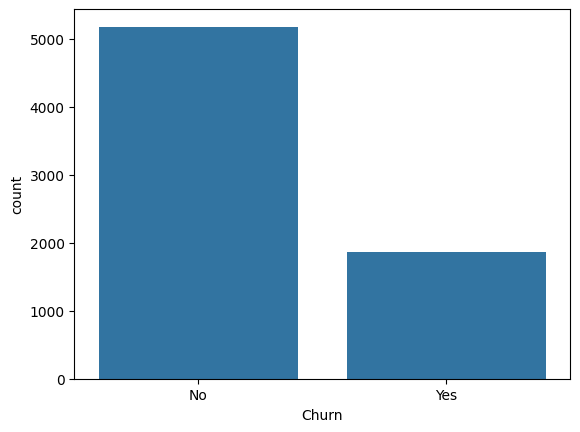

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.show()

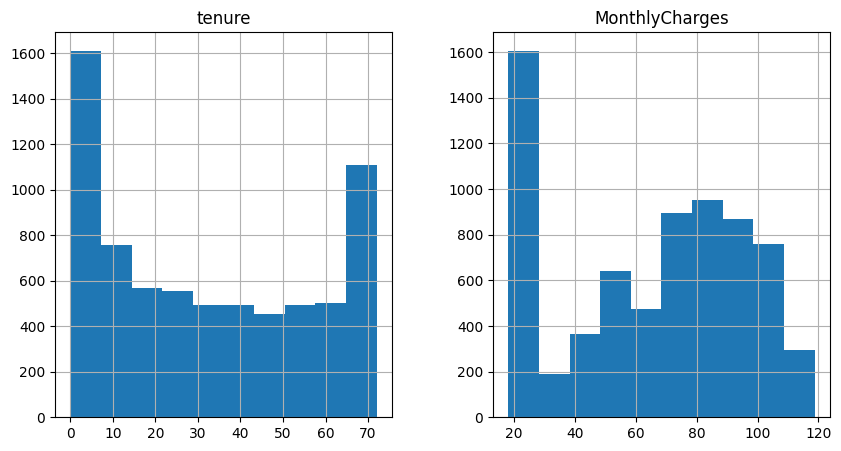

In [6]:
num_cols = ["tenure","MonthlyCharges"]

df[num_cols].hist(figsize=(10,5))
plt.show()

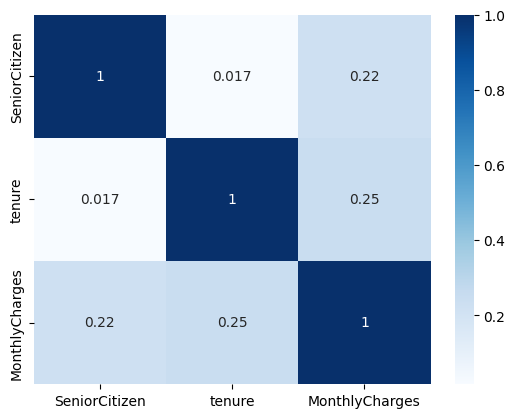

In [7]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")
plt.show()

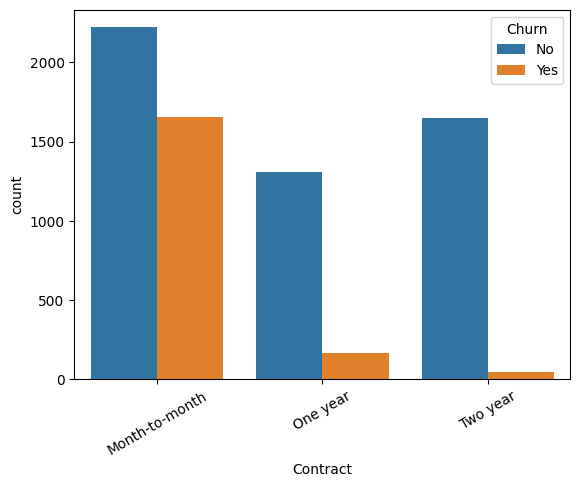

In [8]:
sns.countplot(x="Contract",
              hue="Churn",
              data=df)
plt.xticks(rotation=30)
plt.show()

In [9]:
df.drop("customerID", axis=1, inplace=True)

In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)

y = df["Churn"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Create a pipeline that fills missing values with the median before training
lr = make_pipeline(
    SimpleImputer(strategy='median'),
    LogisticRegression()
)

In [25]:
lr.fit(X_train, y_train)

c:\Users\rosha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('simpleimputer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,penalty,'l2'


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [20]:
def evaluate(model):

    pred = model.predict(X_test)

    return {

        "accuracy":accuracy_score(y_test,pred),

        "precision":precision_score(y_test,pred),

        "recall":recall_score(y_test,pred),

        "f1":f1_score(y_test,pred)

    }

In [26]:
evaluate(lr)

{'accuracy': 0.7984386089425124,
 'precision': 0.6451612903225806,
 'recall': 0.5347593582887701,
 'f1': 0.5847953216374269}

In [22]:
import mlflow

mlflow.set_experiment("Telco Churn")

2026/07/23 12:15:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/23 12:15:08 INFO mlflow.store.db.utils: Updating database tables
2026/07/23 12:15:11 INFO mlflow.tracking.fluent: Experiment with name 'Telco Churn' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/rosha/Desktop/Roshan/mlops_v2/telco-churn-mlops/notebooks/mlruns/1', creation_time=1784789111499, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784789111499, lifecycle_stage='active', name='Telco Churn', tags={}, trace_location=None, workspace='default'>

In [32]:
import yaml
import numpy as np
import mlflow
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- FIX: Teach PyYAML how to serialize numpy dtypes safely ---
def numpy_dtype_representer(dumper, data):
    return dumper.represent_scalar('tag:yaml.org,2002:str', str(data))

yaml.add_representer(np.dtype, numpy_dtype_representer)
yaml.SafeDumper.add_representer(np.dtype, numpy_dtype_representer)
# -------------------------------------------------------------

def train_with_mlflow(name, model):
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred)
        rec = recall_score(y_test, pred)
        f1 = f1_score(y_test, pred)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1", f1)

        # FIX: Bypass skops validation entirely using cloudpickle
        mlflow.sklearn.log_model(
            sk_model=model, 
            artifact_path=name,
            serialization_format="cloudpickle"
        )


In [33]:
train_with_mlflow("Logistic Regression", lr)

train_with_mlflow("Random Forest", rf)

train_with_mlflow("XGBoost", xgb)



c:\Users\rosha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/07/23 12:25:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/23 12:25:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommen

In [34]:
mlflow.log_params({
    "max_iter":1000
})

In [35]:
mlflow.log_params({

    "n_estimators":200,

    "max_depth":None

})

In [37]:
import joblib

joblib.dump(
    rf,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

In [38]:
model = joblib.load(
    "../models/best_model.pkl"
)

prediction = model.predict(X_test)